In [1]:
# import libraries
from dd.autoref import BDD
from itertools import product
import math
import operator

from __future__ import annotations
from typing import Any

import graphviz

import numpy as np
from scipy.stats import norm

In [2]:
# source code
from utils_ADD import *
from utils_transition import *
from utils_SPUDD import *

In [5]:
#!pip install graphviz
#!sudo apt-get install graphviz

#### Create state and action spaces

In [3]:
# create states and actions
states = [0, 50, 100, 150]
n_states = len(states)
subsystems = ["X", "Y", "Z"]

# action_set: each column is an action, rows are (a_X, a_Y, a_Z)
# col 0 -> action applied to X only
# col 1 -> action applied to Y only
# col 2 -> action applied to Z only
action_set = np.array([[1, 0, 0],
                       [0, 1, 0],
                       [0, 0, 1]])
action_cost = {"a1": 10, "a2": 10, "a3": 0}

#### Create instance of ADD manager

In [4]:
mgr = ADD(states)

#### Create reward ADD

##### Create reward function

In [5]:
# reward function
def reward_fn(s, a):
    return s["X"] + s["Y"] + s["Z"] + action_cost[a]

##### Build adds

In [6]:
reward_adds = {
    a: mgr.build(lambda s, a=a: reward_fn(s, a), subsystems)
    for a in action_cost
}

##### Test evaluation

In [7]:
print(mgr.evaluate(reward_adds["a1"], {"X": 50, "Y": 100, "Z": 150}))

##### Count nodes in each ADD

In [8]:
for a, add in reward_adds.items():
    print(f"{a}: {mgr.count_nodes(add)} nodes, {mgr.count_leaves(add)} leaves")

##### Visualize ADD for a1

In [51]:
dot_str = mgr.to_dot(reward_adds["a1"], title="Reward ADD (a1)")
graphviz.Source(dot_str)

### Create transition ADD

##### Parameter values for biological dynamics

In [7]:
params = {
    "p_detect": 0.8, # probability of detection
    "st_mean": 30, # mean of shared annual random intercept
    "st_sd": 50, # sd of shared annual random intercept
    "rho": 2, # growth rate
    "dd": 150, # carrying capacity
    "p_increase": 1 
}

##### Function for getting transition matrix for one subsystem and one action


In [8]:
# transition matrix for one subsystem and one action
def get_transition(params, states, a_binary):
    """
    Returns T[s', s] = P(s' | s, a) for a single subsystem and action.
    a_binary: 1 if action applied to this subsystem, 0 otherwise.
    """
    states = np.array(states, dtype=float)
    n = len(states)

    # get probability of capture
    pcap = min(params["p_detect"] * params["p_increase"], 1.0) if a_binary else 0.0

    # random intercept (i.e., environmental variation)
    prob_int = norm.pdf(states, params["st_mean"], params["st_sd"])
    prob_int = prob_int / prob_int.sum()

    out = np.zeros((n, n))

    for j, s in enumerate(states):

        # remaining after capture
        survived = s * (1 - pcap)
        
        lambda_next = (
            states + survived +
            params["rho"] * survived * (1 - survived / params["dd"])
        )

        prob = np.zeros(n)
        for i, lam in enumerate(lambda_next):
            idx = np.argmin(np.abs(lam - states))
            prob[idx] += prob_int[i]

        out[:, j] = prob / prob.sum()

    return out   # shape: (n_next, n_current)

##### Check that transition matrix is different when action is applied vs. not applied

In [9]:
# action applied
T_applied = get_transition(params, states, a_binary=1)
print(T_applied)

[[0.38143111 0.         0.         0.        ]
 [0.42154657 0.38143111 0.38143111 0.        ]
 [0.17138805 0.42154657 0.42154657 0.38143111]
 [0.02563427 0.19702232 0.19702232 0.61856889]]


In [10]:
# action not applied
T_not_applied = get_transition(params, states, a_binary=0)
print(T_not_applied)

[[0.38143111 0.         0.         0.        ]
 [0.42154657 0.         0.         0.        ]
 [0.17138805 0.38143111 0.         0.        ]
 [0.02563427 0.61856889 1.         1.        ]]


##### Build transition ADDs

In [11]:
# get number of actions
n_actions = action_set.shape[1]

# get transition adds
transition_adds = build_transition_adds(mgr, get_transition, params, states, action_set, n_actions,
                                        subsystems)

Action 0, X: 11 nodes, 7 leaves
Action 0, Y: 11 nodes, 7 leaves
Action 0, Z: 11 nodes, 7 leaves
Action 1, X: 11 nodes, 7 leaves
Action 1, Y: 11 nodes, 7 leaves
Action 1, Z: 11 nodes, 7 leaves
Action 2, X: 11 nodes, 7 leaves
Action 2, Y: 11 nodes, 7 leaves
Action 2, Z: 11 nodes, 7 leaves


In [16]:
# Evaluate: P(X'=100, Y'=50, Z'=0 | X=50, Y=100, Z=150, a=0)
assignment = {"X": 50, "Y": 100, "Z": 150,
              "X_p": 100, "Y_p": 50, "Z_p": 0}
print(mgr.evaluate(transition_adds[0]["Z"], assignment))

0.3814311104263876


##### Show transition ADDs for different actions

In [34]:
# Action 0, subsystem Z
dot_a0 = mgr.to_dot(transition_adds[0]["Z"], title="P(Z'|Z, a=0)")
graphviz.Source(dot_a0)

In [36]:
# Action 1, subsystem Z
dot_a1 = mgr.to_dot(transition_adds[1]["Z"], title="P(Z'|Z, a=1)")
graphviz.Source(dot_a1)

In [37]:
# Action 2, subsystem Z
dot_a2 = mgr.to_dot(transition_adds[2]["Z"], title="P(Z'|Z, a=1)")
graphviz.Source(dot_a2)

##### Compare to transition matrix to show that the transition ADD is equivalent

In [38]:
# compare to transition matrix
T = get_transition(params, states, a_binary=1)
print(T)

## SPUDD algorithm

##### Set discount and tolerance threshold for SPUDD value iteration algorithm

In [12]:
DISCOUNT = 0.95
TOLERANCE = 0.01

##### Run SPUDD algorithm

In [13]:
V, policy_adds = spudd(
    mgr,
    subsystems,
    reward_adds,
    transition_adds,
    discount=DISCOUNT,
    tolerance=TOLERANCE
)

Iteration 10: delta = 277.894892, nodes = 306


Iteration 20: delta = 166.385937, nodes = 313


Iteration 30: delta = 99.621407, nodes = 313


Iteration 40: delta = 59.647016, nodes = 306


Iteration 50: delta = 35.712872, nodes = 314


...

Iteration 170: delta = 0.075798, nodes = 306


Iteration 180: delta = 0.045383, nodes = 321


Iteration 190: delta = 0.027172, nodes = 309


Iteration 200: delta = 0.016269, nodes = 313


Iteration 210: delta = 0.009741, nodes = 313
Converged after 210 iterations.


##### Get the optimal action for an example state

In [12]:
get_optimal_action(mgr, reward_adds, policy_adds, {"X": 50, "Y": 100, "Z": 0})

State {'X': 50, 'Y': 100, 'Z': 0}: Q-values = {'a1': np.float64(8324.584521874493), 'a2': np.float64(8300.858679720921), 'a3': np.float64(8359.884511314738)}, optimal action = a3


2

##### Get the optimal value for each state (optimal value function)

In [14]:
df = get_value_df(mgr, V, states)
print(df)

      X    Y    Z            V
0     0    0    0  7900.219365
1     0    0   50  8102.737224
2     0    0  100  8173.191711
3     0    0  150  8223.191711
4     0   50    0  8101.991744
..  ...  ...  ...          ...
59  150  100  150  8787.455367
60  150  150    0  8527.993235
61  150  150   50  8719.337389
62  150  150  100  8787.455367
63  150  150  150  8837.455367

[64 rows x 4 columns]


##### Plot the optimal value for each state (optimal value function)

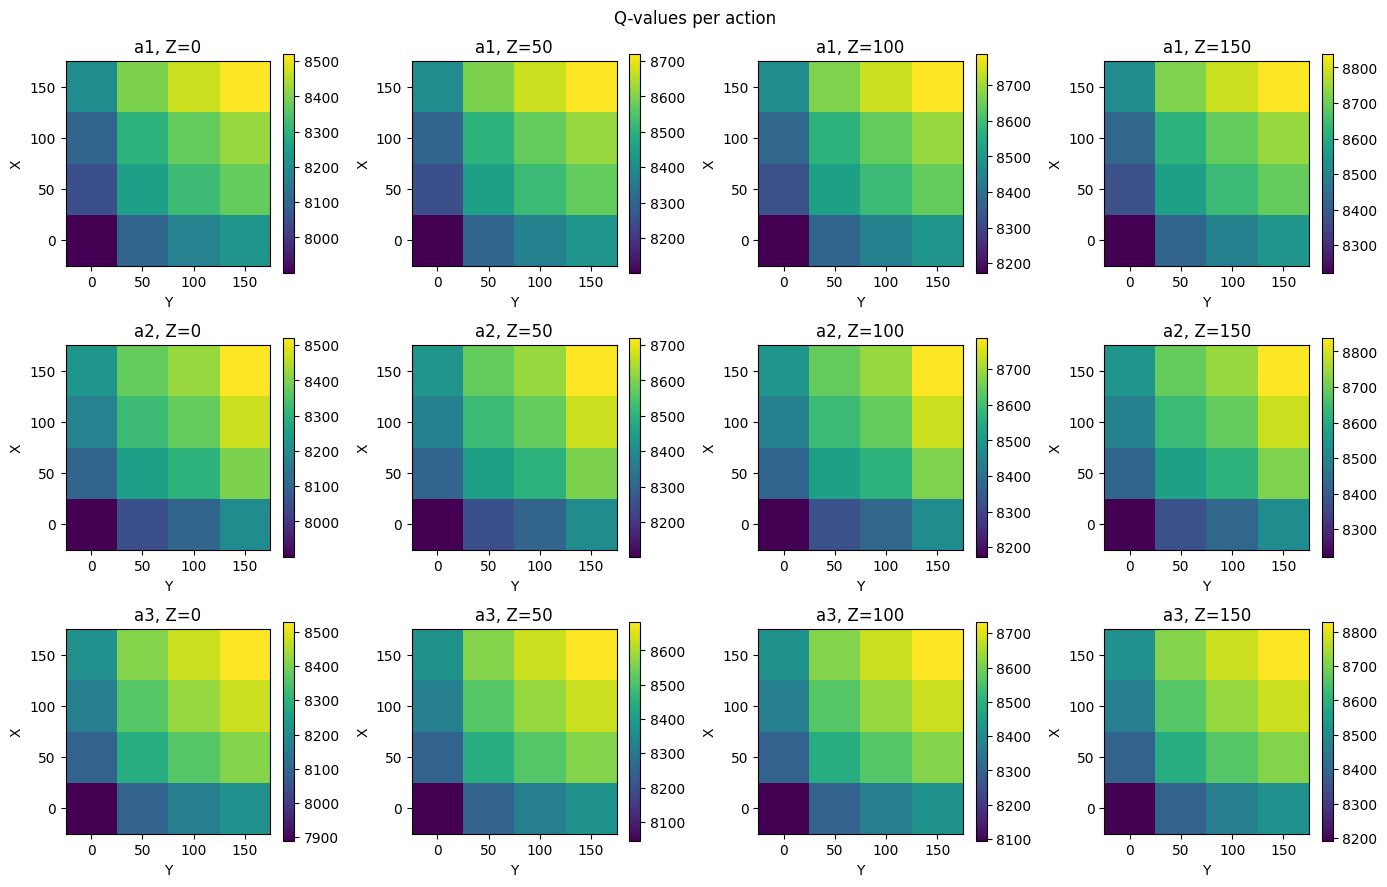

In [14]:
plt = plot_qvalues(mgr, reward_adds, policy_adds, states)
plt.show()

## Compare to classic MDP

##### Build transition matrix

In [ ]:
# transition matrix: dims = length(states), length(states), length(actions)

In [15]:
# create full list of states
rows = []

for x, y, z in itertools.product(states, repeat=3):
    state = {"X": x, "Y": y, "Z": z}
    rows.append({"X": x, "Y": y, "Z": z})

states_all = pd.DataFrame(rows)
states_all

,X,Y,Z
0,0,0,0
1,0,0,50
2,0,0,100
3,0,0,150
4,0,50,0
...,...,...,...
59,150,100,150
60,150,150,0
61,150,150,50
62,150,150,100


In [55]:
# create empty transition matrix
transition_matrix = np.zeros((states_all.shape[0], states_all.shape[0], action_set.shape[0]))

In [56]:
# s loop
for i in range(states_all.shape[0]):

    s_index_X = np.where(states == states_all.at[i, "X"])[0][0]
    s_index_Y = np.where(states == states_all.at[i, "Y"])[0][0]
    s_index_Z = np.where(states == states_all.at[i, "Z"])[0][0]
    
    # sprime loop
    for j in range(states_all.shape[0]):

        sprime_index_X = np.where(states == states_all.at[j, "X"])[0][0]
        sprime_index_Y = np.where(states == states_all.at[j, "Y"])[0][0]
        sprime_index_Z = np.where(states == states_all.at[j, "Z"])[0][0]

        ##
        # action 1
        ##
        
        prob_x = T_applied[s_index_X, sprime_index_X]
        prob_y = T_not_applied[s_index_Y, sprime_index_Y]
        prob_z = T_not_applied[s_index_Z, sprime_index_Z]

        transition_matrix[i, j, 0] = prob_x * prob_y * prob_z

        ##
        # action 2
        ##
        
        prob_x = T_not_applied[s_index_X, sprime_index_X]
        prob_y = T_applied[s_index_Y, sprime_index_Y]
        prob_z = T_not_applied[s_index_Z, sprime_index_Z]

        transition_matrix[i, j, 1] = prob_x * prob_y * prob_z

        ##
        # action 3
        ##
        
        prob_x = T_not_applied[s_index_X, sprime_index_X]
        prob_y = T_not_applied[s_index_Y, sprime_index_Y]
        prob_z = T_applied[s_index_Z, sprime_index_Z]

        transition_matrix[i, j, 2] = prob_x * prob_y * prob_z

# normalize first dimension
transition_matrix /= transition_matrix.sum(axis=0, keepdims=True)

##### Build utility matrix

In [ ]:
# utility matrix: dims = length(states), length(actions)

In [63]:
# create empty utility matrix
utility_matrix = np.zeros((states_all.shape[0], action_set.shape[0]))

In [64]:
action_names = ["a1", "a2", "a3"]

for i in range(states_all.shape[0]):
    for j in range(action_set.shape[0]):

        utility_matrix[i, j] = reward_fn(s = states_all.iloc[i].to_dict(), a = action_names[j])

##### solve value iteration

In [65]:
# Action value vectors
Vt = np.zeros(states_all.shape[0])
Vtplus = np.zeros(states_all.shape[0])

# Optimal policy vector
D = np.zeros(states_all.shape[0])

# Convergence criterion
did_converge = False

iteration_count = 0
while not did_converge:
    # Q matrix: rows = states, cols = actions
    Q = np.zeros((states_all.shape[0], len(action_names)))

    for i in range(len(action_names)):
        Q[:, i] = utility_matrix[:, i] + DISCOUNT * (transition_matrix[:, :, i].T @ Vtplus)

    # Optimal action value at time t
    Vt = Q.max(axis=1)

    # Check convergence
    if np.max(np.abs(Vtplus - Vt)) < TOLERANCE:
        did_converge = True

    Vtplus = Vt.copy()

    iteration_count += 1
print("Matrix VI iterations:", iteration_count)

Matrix VI iterations: 210


##### Show that the value function via SPUDD and matrix value iteration are the same

In [67]:
np.allclose(Vt, df["V"].values)

True